## ANALISIS EXPLORATORIO DE DATOS

#### Inspeccionar dataset (archivo CSV)

#### Importamos librerias

In [1]:
!{sys.executable} -m pip install -r requirements.txt

'{sys.executable}' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
import warnings
import re
from utils.plot_functions import *
 
warnings.filterwarnings("ignore")

#### Inspeccionamos el dataset

In [3]:
df = pd.read_csv(r'C:\Users\renat\Documents\Facultad\5to año\Ciencia de Datos (1C)\Ciencia-de-Datos\Reviews.csv')

In [4]:
df.shape

(568454, 10)

In [5]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [6]:
df.isnull().sum()

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

In [7]:
df['ProfileName'] = df['ProfileName'].fillna('UNKNOWN_USER')
df['Summary'] = df['Summary'].fillna('NO SUMMARY')

In [8]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='str')

In [9]:
df.isnull().sum()

Id                        0
ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   0
Text                      0
dtype: int64

In [10]:
df["Time"] = pd.to_datetime(df["Time"], unit="s")

In [11]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype        
---  ------                  --------------   -----        
 0   Id                      568454 non-null  int64        
 1   ProductId               568454 non-null  str          
 2   UserId                  568454 non-null  str          
 3   ProfileName             568454 non-null  str          
 4   HelpfulnessNumerator    568454 non-null  int64        
 5   HelpfulnessDenominator  568454 non-null  int64        
 6   Score                   568454 non-null  int64        
 7   Time                    568454 non-null  datetime64[s]
 8   Summary                 568454 non-null  str          
 9   Text                    568454 non-null  str          
dtypes: datetime64[s](1), int64(4), str(5)
memory usage: 312.9 MB


,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,568454.000000,568454.000000,568454.00000,568454.000000,568454
mean,284227.500000,1.743817,2.22881,4.183199,2011-01-28 23:16:44
min,1.000000,0.000000,0.00000,1.000000,1999-10-08 00:00:00
25%,142114.250000,0.000000,0.00000,4.000000,2010-04-15 00:00:00
50%,284227.500000,0.000000,1.00000,5.000000,2011-07-20 00:00:00
75%,426340.750000,2.000000,2.00000,5.000000,2012-03-26 00:00:00
max,568454.000000,866.000000,923.00000,5.000000,2012-10-26 00:00:00
std,164098.679298,7.636513,8.28974,1.310436,NaN


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.duplicated(
    subset=["ProductId","UserId","Text"]
).sum()

np.int64(1309)

In [14]:
df.isnull().sum()

Id                        0
ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   0
Text                      0
dtype: int64

## Creamos Variables Auxiliares para los gráficos

In [15]:
df["review_length"] = (
    df["Text"]
      .str.split()
      .str.len()
)

In [16]:
df["summary_length"] = (
    df["Summary"]
      .str.split()
      .str.len()
)

In [17]:
df["helpfulness_ratio"] = (
    df["HelpfulnessNumerator"] /
    df["HelpfulnessDenominator"].replace(0,np.nan)
)

df["helpfulness_ratio"] = (
    df["helpfulness_ratio"]
    .fillna(0)
)

## EDA

## Distribuciones Univariadas

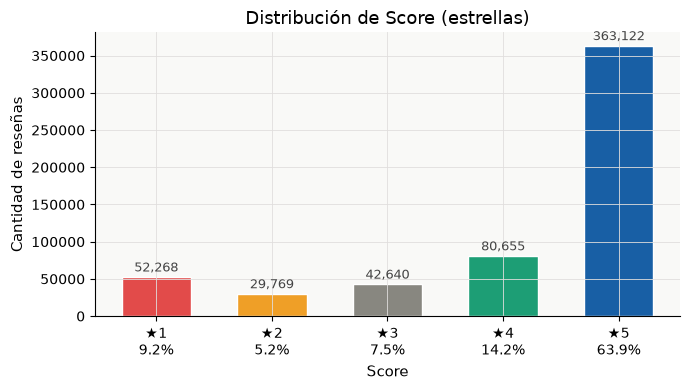

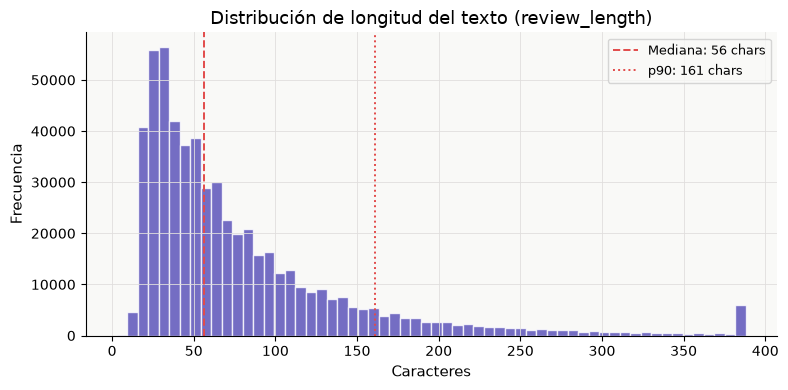

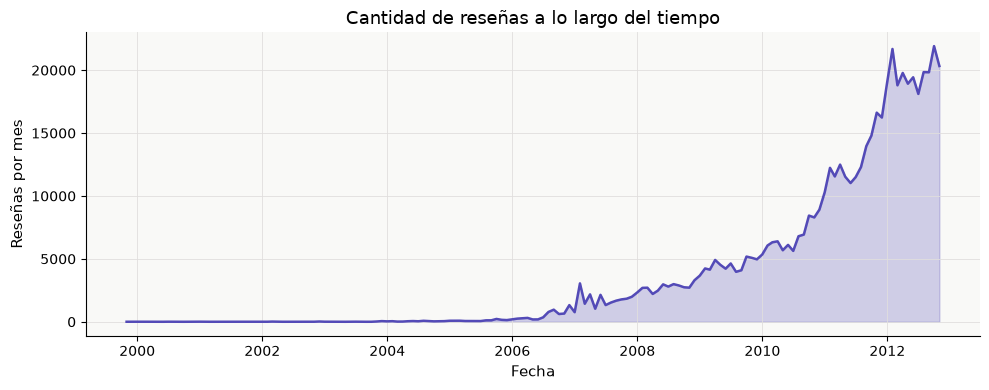

In [18]:
df_score = plot_score_distribution(df)
df_longitud_texto = plot_text_length_distribution(df)
df_grafico_3 = plot_reviews_over_time(df)

## Variables Categóricas

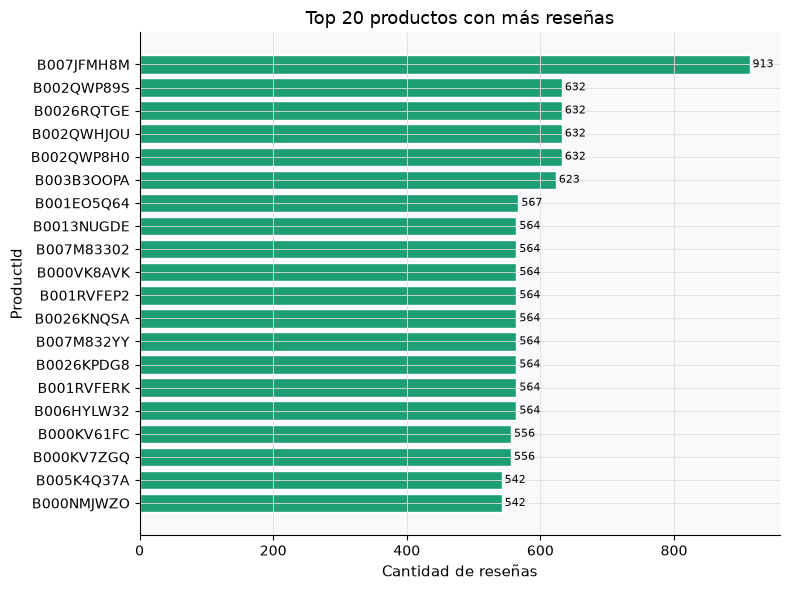

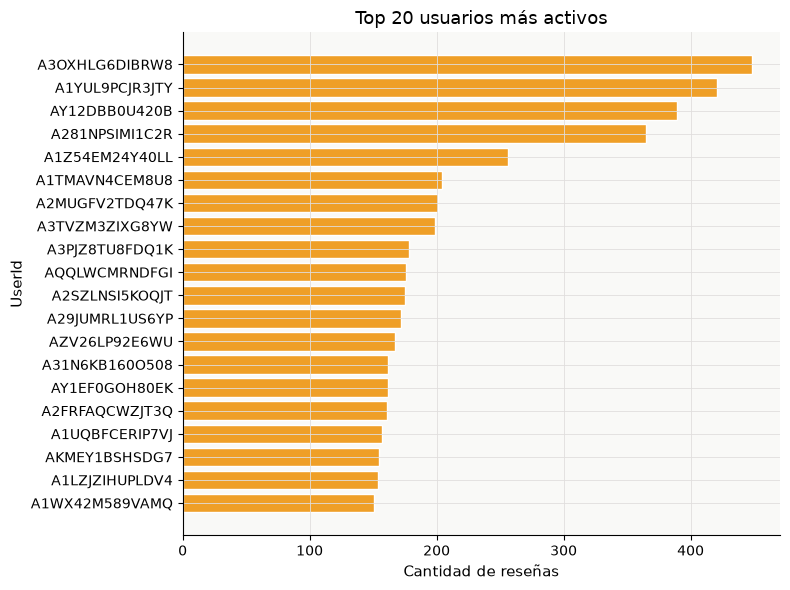

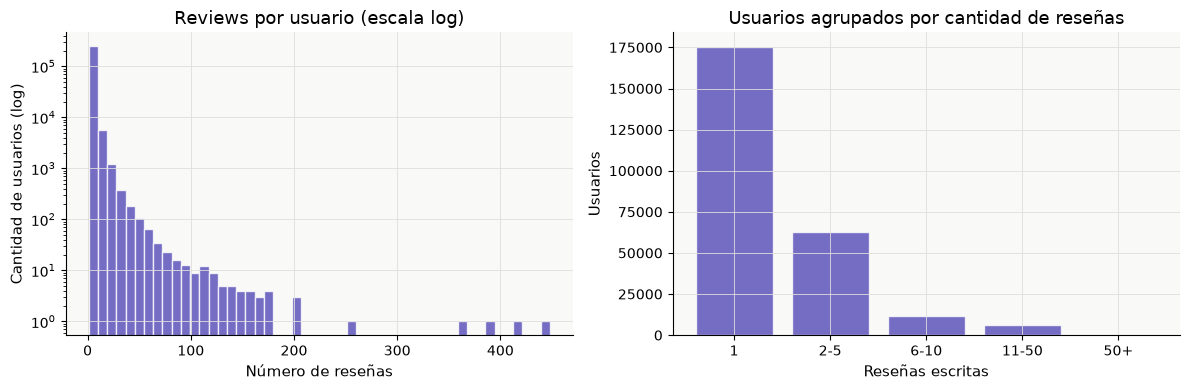

In [19]:
df_graf = plot_top_products(df)
df_graf_2 = plot_top_users(df)
df_graf_3 = plot_reviews_per_user_distribution(df)

## Helpfulness

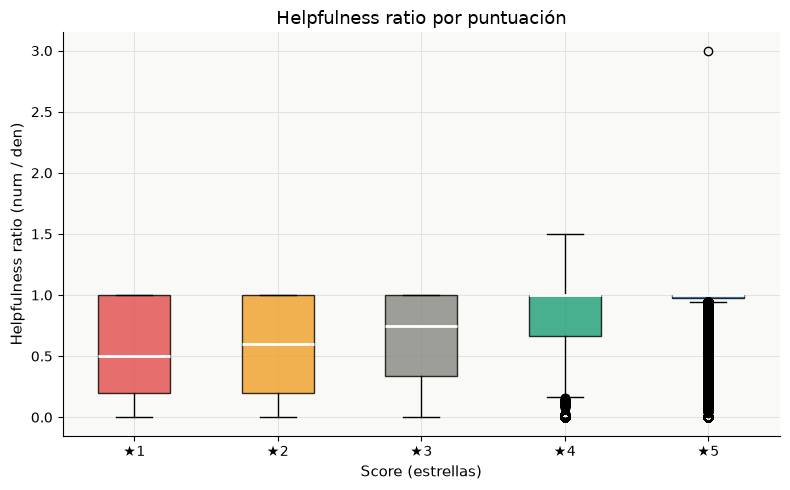

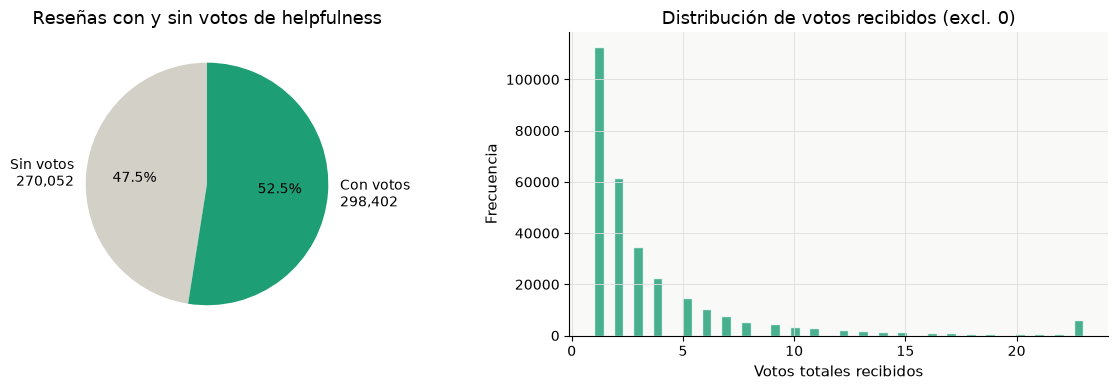

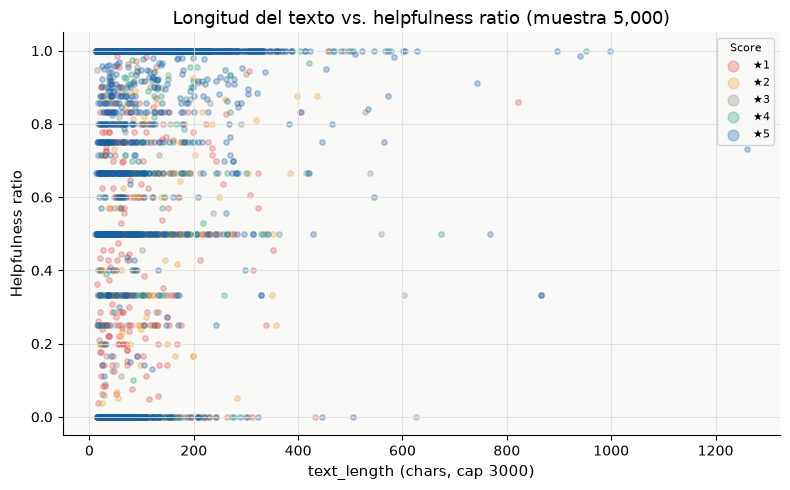

In [20]:
graficos_text = plot_helpfulness_ratio_by_score(df)
graficos_text_1 = plot_denominator_distribution(df)
graficos_text_2 = plot_text_length_vs_helpfulness(df)

<Axes: xlabel='Score', ylabel='count'>

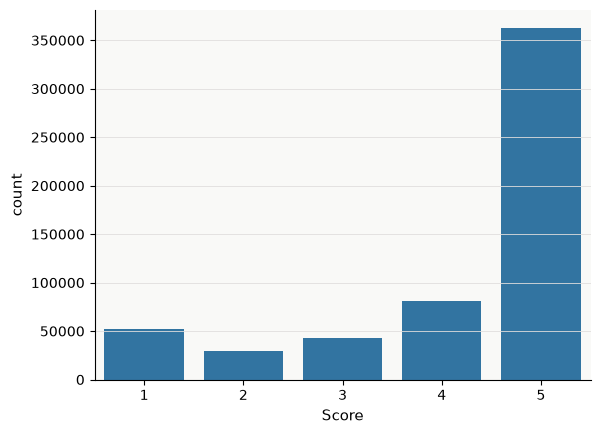

In [21]:
sns.countplot(data=df,x="Score")

<Axes: xlabel='review_length', ylabel='Count'>

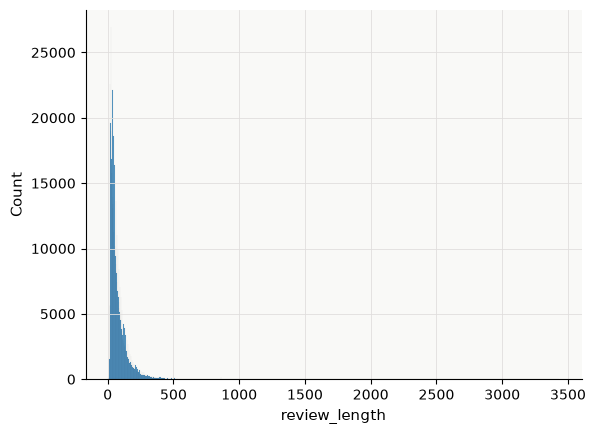

In [22]:
sns.histplot(df["review_length"])

<Axes: xlabel='Score', ylabel='review_length'>

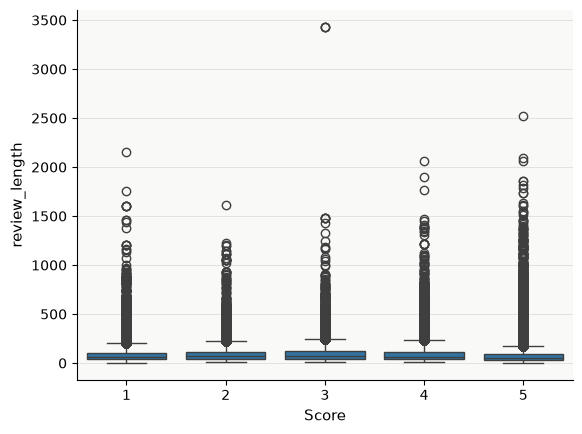

In [23]:
sns.boxplot(
    data=df,
    x="Score",
    y="review_length"
)

<Axes: xlabel='helpfulness_ratio', ylabel='Count'>

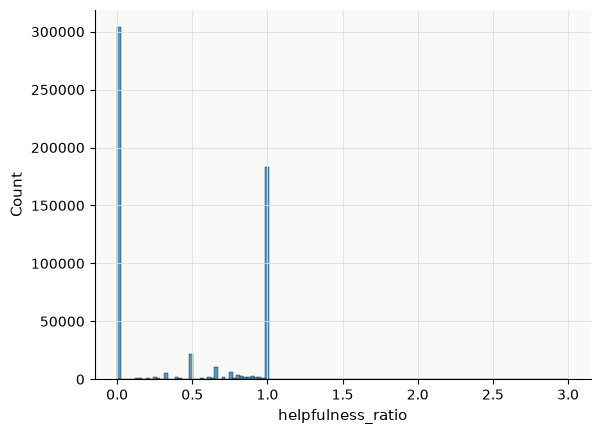

In [24]:
sns.histplot(df["helpfulness_ratio"])